Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/new_merged_postprocess_smc_20140101_dailymean.png


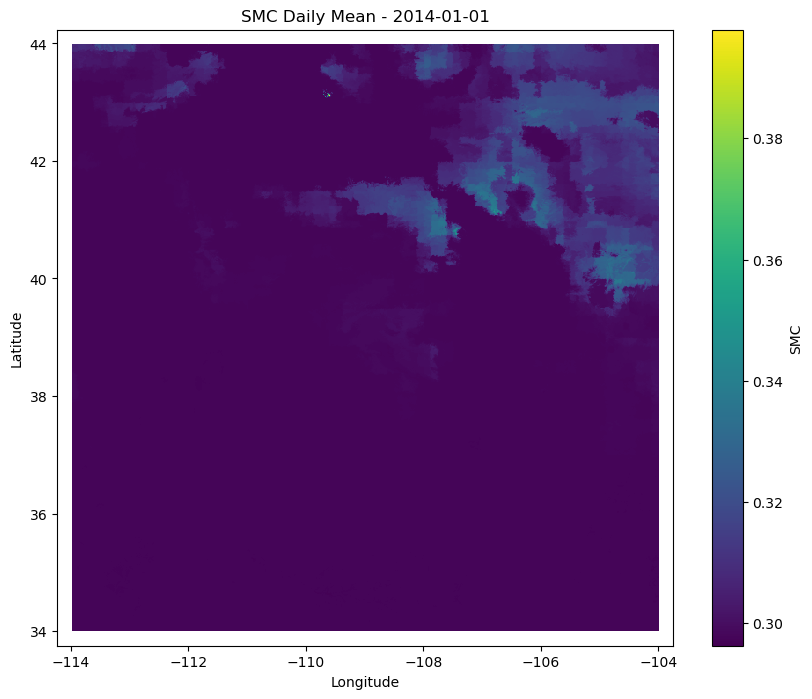

In [2]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

#path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_100hru_100bh_bug_checking_new_ben_prep/"

file = path + "postprocess/output_dir/20140101.nc"

with nc.Dataset(file) as ds:

    lon = ds.variables["lon"][:]
    lat = ds.variables["lat"][:]

    # Daily mean over the 8 three-hourly timesteps
    smc = np.nanmean(ds.variables["smc"][:], axis=0)

    smc[smc <= -9990] = np.nan

extent = [
    lon.min(),
    lon.max(),
    lat.min(),
    lat.max()
]

plt.figure(figsize=(10,8))

im = plt.imshow(
    smc,
    origin="lower",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SMC Daily Mean - 2014-01-01")

plt.colorbar(im, label="SMC")

outfile = os.path.join(
    outputdir,
    "new_merged_postprocess_smc_20140101_dailymean.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

Winter files found: 87
Processed 10/87 files
Processed 20/87 files
Processed 30/87 files
Processed 40/87 files
Processed 50/87 files
Processed 60/87 files
Processed 70/87 files
Processed 80/87 files
Processed 87/87 files
Valid winter files: 87
Expected 3-hourly timesteps: 696
Winter SMC minimum: 0.12425490103169591
Winter SMC maximum: 0.49232105448328217
Winter SMC basin mean: 0.29281109267206185
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/new_merged_postprocess_smc_winter_2014_mean.png


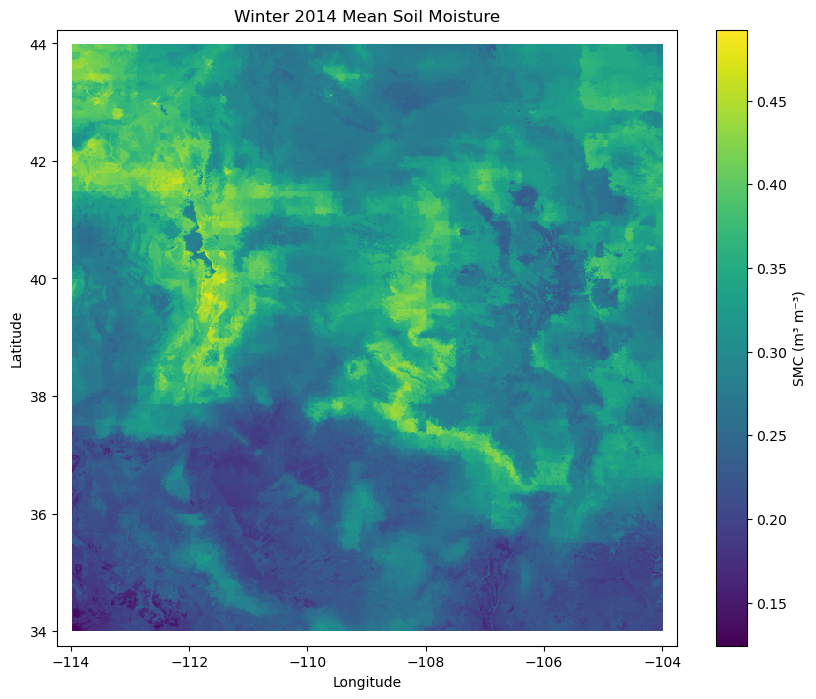

In [3]:
import os
import glob
from datetime import datetime

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/output_plots"
)
os.makedirs(outputdir, exist_ok=True)

path = (
    "/scratch/alpine/battobrah@xsede.org/"
    "Rice_NMT_Snow/upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_100hru_"
    "100bh_bug_checking_new_ben_prep"
)

postprocess_dir = os.path.join(
    path,
    "postprocess",
    "output_dir"
)

# Find all daily NetCDF files
all_files = sorted(glob.glob(os.path.join(postprocess_dir, "2014????.nc")))

# Select Winter 2014: January, February, and December
winter_files = []

for file in all_files:
    filename = os.path.basename(file)
    file_date = datetime.strptime(filename[:8], "%Y%m%d")

    if file_date.year == 2014 and file_date.month in [1, 2, 12]:
        winter_files.append(file)

print("Winter files found:", len(winter_files))

if not winter_files:
    raise FileNotFoundError(
        f"No Winter 2014 files found in:\n{postprocess_dir}"
    )

# Read coordinates from the first file
with nc.Dataset(winter_files[0]) as ds:
    lon = np.asarray(ds.variables["lon"][:])
    lat = np.asarray(ds.variables["lat"][:])

    first_smc = np.ma.filled(
        ds.variables["smc"][:],
        np.nan
    ).astype(np.float64)

# Initialize accumulators
spatial_shape = first_smc.shape[-2:]

smc_sum = np.zeros(spatial_shape, dtype=np.float64)
smc_count = np.zeros(spatial_shape, dtype=np.int64)

# Process every daily file
for number, file in enumerate(winter_files, start=1):

    with nc.Dataset(file) as ds:
        smc = np.ma.filled(
            ds.variables["smc"][:],
            np.nan
        ).astype(np.float64)

    # Remove HydroBlocks fill values
    smc[smc <= -9990] = np.nan

    # Sum all valid 3-hourly values
    smc_sum += np.nansum(smc, axis=0)
    smc_count += np.sum(np.isfinite(smc), axis=0)

    if number % 10 == 0 or number == len(winter_files):
        print(f"Processed {number}/{len(winter_files)} files")

# Mean across all valid Winter 2014 timesteps
winter_smc = np.full(spatial_shape, np.nan, dtype=np.float64)

valid = smc_count > 0
winter_smc[valid] = smc_sum[valid] / smc_count[valid]

print("Valid winter files:", len(winter_files))
print("Expected 3-hourly timesteps:", len(winter_files) * 8)
print("Winter SMC minimum:", np.nanmin(winter_smc))
print("Winter SMC maximum:", np.nanmax(winter_smc))
print("Winter SMC basin mean:", np.nanmean(winter_smc))

extent = [
    float(np.nanmin(lon)),
    float(np.nanmax(lon)),
    float(np.nanmin(lat)),
    float(np.nanmax(lat))
]

plt.figure(figsize=(10, 8))

im = plt.imshow(
    winter_smc,
    origin="lower",
    extent=extent,
    cmap="viridis",
    interpolation="nearest",
    aspect="auto"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Winter 2014 Mean Soil Moisture")
plt.colorbar(im, label=r"SMC (m³ m⁻³)")

outfile = os.path.join(
    outputdir,
    "new_merged_postprocess_smc_winter_2014_mean.png"
)

plt.savefig(
    outfile,
    dpi=250,
    bbox_inches="tight"
)

print("Saved:", outfile)

plt.show()

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/new_static_dem_full_domain_from_vrt.png


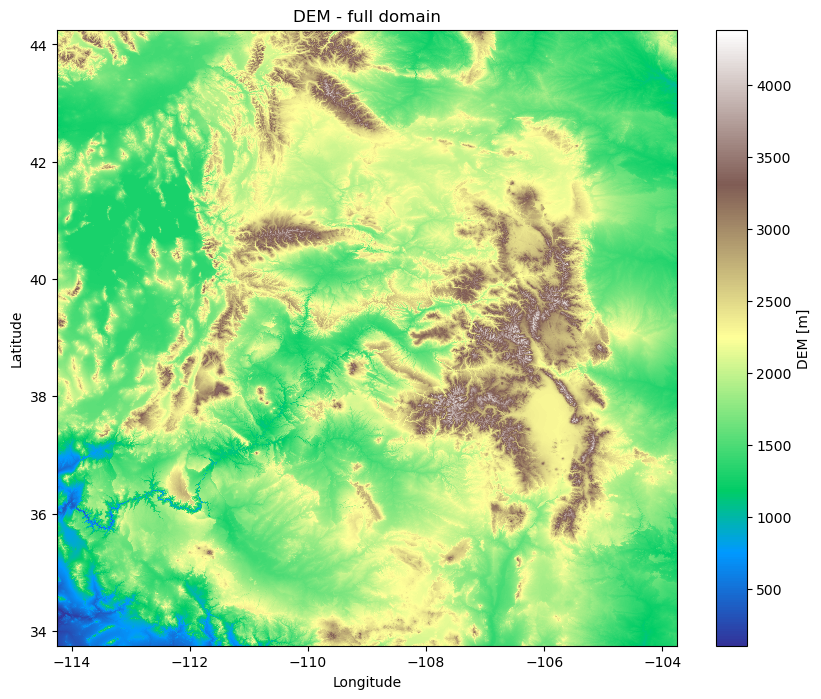

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_100hru_100bh_bug_checking_new_ben_prep/"


dem_file = path + "postprocess/dem.vrt"

dem = gdal_tools.read_raster(dem_file).astype(float)
metad = gdal_tools.retrieve_metadata(dem_file)

dem[dem == -9999] = np.nan

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

plt.figure(figsize=(10, 8))

im = plt.pcolormesh(
    coords_x,
    coords_y,
    np.flipud(dem),
    cmap="terrain",
    shading="auto"
)

plt.colorbar(im, label="DEM [m]")
plt.title("DEM - full domain")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

outfile = os.path.join(outputdir, "new_static_dem_full_domain_from_vrt.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Winter files found: 87
Processed 10/87 files
Processed 20/87 files
Processed 30/87 files
Processed 40/87 files
Processed 50/87 files
Processed 60/87 files
Processed 70/87 files
Processed 80/87 files
Processed 87/87 files
Valid winter files: 87
Expected 3-hourly timesteps: 696
Winter FSNO minimum: 0.0
Winter FSNO maximum: 0.9987408573814165
Winter FSNO basin mean: 0.5308020061417154
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/new_merged_postprocess_fsno_winter_2014_mean.png


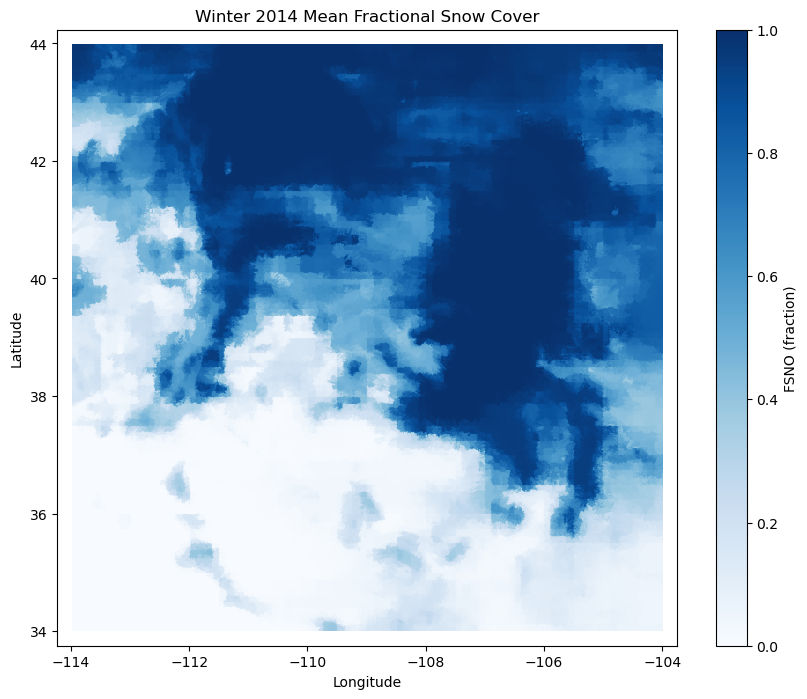

In [5]:
import os
import glob
from datetime import datetime

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/output_plots"
)
os.makedirs(outputdir, exist_ok=True)

path = (
    "/scratch/alpine/battobrah@xsede.org/"
    "Rice_NMT_Snow/upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_100hru_"
    "100bh_bug_checking_new_ben_prep"
)

postprocess_dir = os.path.join(
    path,
    "postprocess",
    "output_dir"
)

# Find all daily 2014 files
all_files = sorted(
    glob.glob(os.path.join(postprocess_dir, "2014????.nc"))
)

# Winter 2014: January, February and December
winter_files = []

for file in all_files:
    filename = os.path.basename(file)
    file_date = datetime.strptime(filename[:8], "%Y%m%d")

    if file_date.year == 2014 and file_date.month in [1, 2, 12]:
        winter_files.append(file)

print("Winter files found:", len(winter_files))

if not winter_files:
    raise FileNotFoundError(
        f"No Winter 2014 files found in:\n{postprocess_dir}"
    )

# Read coordinates and determine spatial shape
with nc.Dataset(winter_files[0]) as ds:
    lon = np.asarray(ds.variables["lon"][:])
    lat = np.asarray(ds.variables["lat"][:])

    first_fsno = np.ma.filled(
        ds.variables["fsno"][:],
        np.nan
    ).astype(np.float64)

spatial_shape = first_fsno.shape[-2:]

fsno_sum = np.zeros(spatial_shape, dtype=np.float64)
fsno_count = np.zeros(spatial_shape, dtype=np.int64)

# Accumulate all valid 3-hourly FSNO values
for number, file in enumerate(winter_files, start=1):

    with nc.Dataset(file) as ds:
        fsno = np.ma.filled(
            ds.variables["fsno"][:],
            np.nan
        ).astype(np.float64)

    # Remove HydroBlocks fill values and invalid fractions
    fsno[fsno <= -9990] = np.nan
    fsno[(fsno < 0.0) | (fsno > 1.0)] = np.nan

    fsno_sum += np.nansum(fsno, axis=0)
    fsno_count += np.sum(np.isfinite(fsno), axis=0)

    if number % 10 == 0 or number == len(winter_files):
        print(f"Processed {number}/{len(winter_files)} files")

# Winter mean FSNO
winter_fsno = np.full(spatial_shape, np.nan, dtype=np.float64)

valid = fsno_count > 0
winter_fsno[valid] = fsno_sum[valid] / fsno_count[valid]

print("Valid winter files:", len(winter_files))
print("Expected 3-hourly timesteps:", len(winter_files) * 8)
print("Winter FSNO minimum:", np.nanmin(winter_fsno))
print("Winter FSNO maximum:", np.nanmax(winter_fsno))
print("Winter FSNO basin mean:", np.nanmean(winter_fsno))

extent = [
    float(np.nanmin(lon)),
    float(np.nanmax(lon)),
    float(np.nanmin(lat)),
    float(np.nanmax(lat))
]

plt.figure(figsize=(10, 8))

im = plt.imshow(
    winter_fsno,
    origin="lower",
    extent=extent,
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest",
    aspect="auto"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Winter 2014 Mean Fractional Snow Cover")
plt.colorbar(im, label="FSNO (fraction)")

outfile = os.path.join(
    outputdir,
    "new_merged_postprocess_fsno_winter_2014_mean.png"
)

plt.savefig(
    outfile,
    dpi=250,
    bbox_inches="tight"
)

print("Saved:", outfile)

plt.show()

Winter files found: 87
Processed 10/87 files
Processed 20/87 files
Processed 30/87 files
Processed 40/87 files
Processed 50/87 files
Processed 60/87 files
Processed 70/87 files
Processed 80/87 files
Processed 87/87 files
Valid winter files: 87
Expected 3-hourly timesteps: 696
Winter TRAD minimum: 256.3262148890002
Winter TRAD maximum: 286.5261180044591
Winter TRAD basin mean: 270.33487791979906
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/new_merged_postprocess_trad_winter_2014_mean.png


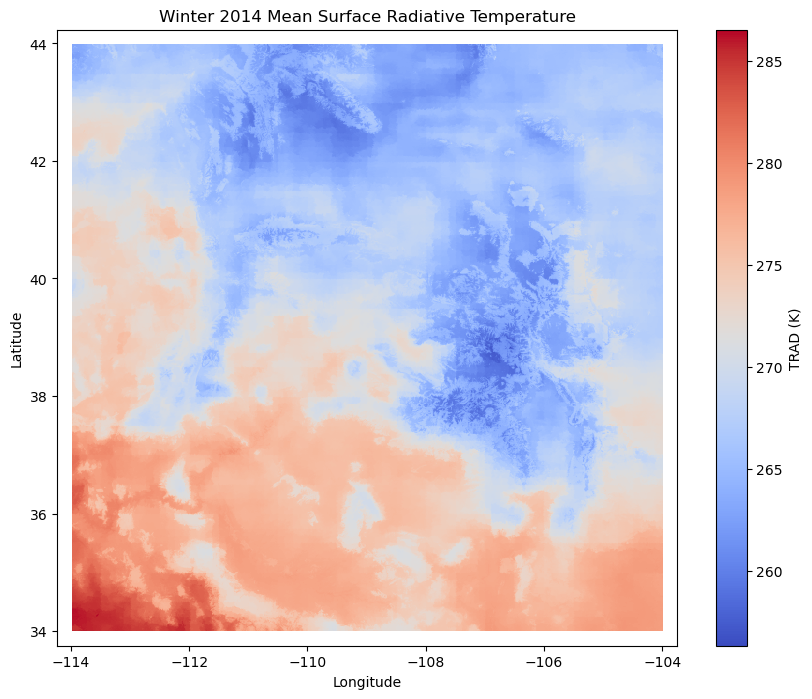

In [6]:
import os
import glob
from datetime import datetime

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/output_plots"
)
os.makedirs(outputdir, exist_ok=True)

path = (
    "/scratch/alpine/battobrah@xsede.org/"
    "Rice_NMT_Snow/upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_100hru_"
    "100bh_bug_checking_new_ben_prep"
)

postprocess_dir = os.path.join(
    path,
    "postprocess",
    "output_dir"
)

# Find all 2014 daily files
all_files = sorted(
    glob.glob(os.path.join(postprocess_dir, "2014????.nc"))
)

# Winter 2014: January, February and December
winter_files = []

for file in all_files:
    filename = os.path.basename(file)
    file_date = datetime.strptime(filename[:8], "%Y%m%d")

    if file_date.year == 2014 and file_date.month in [1, 2, 12]:
        winter_files.append(file)

print("Winter files found:", len(winter_files))

if not winter_files:
    raise FileNotFoundError(
        f"No Winter 2014 files found in:\n{postprocess_dir}"
    )

# Read coordinates and determine the spatial shape
with nc.Dataset(winter_files[0]) as ds:
    lon = np.asarray(ds.variables["lon"][:])
    lat = np.asarray(ds.variables["lat"][:])

    first_trad = np.ma.filled(
        ds.variables["trad"][:],
        np.nan
    ).astype(np.float64)

spatial_shape = first_trad.shape[-2:]

trad_sum = np.zeros(spatial_shape, dtype=np.float64)
trad_count = np.zeros(spatial_shape, dtype=np.int64)

# Accumulate every valid 3-hourly value
for number, file in enumerate(winter_files, start=1):

    with nc.Dataset(file) as ds:
        trad = np.ma.filled(
            ds.variables["trad"][:],
            np.nan
        ).astype(np.float64)

    # Remove HydroBlocks fill values
    trad[trad <= -9990] = np.nan

    trad_sum += np.nansum(trad, axis=0)
    trad_count += np.sum(np.isfinite(trad), axis=0)

    if number % 10 == 0 or number == len(winter_files):
        print(f"Processed {number}/{len(winter_files)} files")

# Winter mean
winter_trad = np.full(spatial_shape, np.nan, dtype=np.float64)

valid = trad_count > 0
winter_trad[valid] = trad_sum[valid] / trad_count[valid]

print("Valid winter files:", len(winter_files))
print("Expected 3-hourly timesteps:", len(winter_files) * 8)
print("Winter TRAD minimum:", np.nanmin(winter_trad))
print("Winter TRAD maximum:", np.nanmax(winter_trad))
print("Winter TRAD basin mean:", np.nanmean(winter_trad))

extent = [
    float(np.nanmin(lon)),
    float(np.nanmax(lon)),
    float(np.nanmin(lat)),
    float(np.nanmax(lat))
]

plt.figure(figsize=(10, 8))

im = plt.imshow(
    winter_trad,
    origin="lower",
    extent=extent,
    cmap="coolwarm",
    interpolation="nearest",
    aspect="auto"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Winter 2014 Mean Surface Radiative Temperature")
plt.colorbar(im, label="TRAD (K)")

outfile = os.path.join(
    outputdir,
    "new_merged_postprocess_trad_winter_2014_mean.png"
)

plt.savefig(
    outfile,
    dpi=250,
    bbox_inches="tight"
)

print("Saved:", outfile)

plt.show()

In [1]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

#path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_full_domain_no_downscale/"

file = path + "postprocess/output_dir/20140101.nc"

with nc.Dataset(file) as ds:

    lon = ds.variables["lon"][:]
    lat = ds.variables["lat"][:]

    # Daily mean over the 8 three-hourly timesteps
    smc = np.nanmean(ds.variables["smc"][:], axis=0)

    smc[smc <= -9990] = np.nan

extent = [
    lon.min(),
    lon.max(),
    lat.min(),
    lat.max()
]

plt.figure(figsize=(10,8))

im = plt.imshow(
    smc,
    origin="lower",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SMC Daily Mean - 2014-01-01")

plt.colorbar(im, label="SMC")

outfile = os.path.join(
    outputdir,
    "new_merged_postprocess_smc_20140101_dailymean.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: b'/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_full_domain_no_downscale/postprocess/output_dir/20140101.nc'

In [1]:
import os
import glob
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/output_plots"
)
os.makedirs(outputdir, exist_ok=True)

# Change this to the experiment you just postprocessed
path = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/"
    "upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_3yr_2hru_"
    "full_domain_no_downscale/"
)

postprocess_dir = os.path.join(path, "postprocess", "output_dir")

years = [2014, 2015, 2016]
variables = ["smc", "fsno"]

annual_maps = {
    variable: {}
    for variable in variables
}

lon = None
lat = None

for year in years:

    files = sorted(
        glob.glob(
            os.path.join(postprocess_dir, f"{year}????.nc")
        )
    )

    print(f"{year}: found {len(files)} daily files", flush=True)

    if not files:
        continue

    sums = {
        variable: None
        for variable in variables
    }

    counts = {
        variable: None
        for variable in variables
    }

    for file_number, file in enumerate(files, start=1):

        if file_number % 50 == 0 or file_number == len(files):
            print(
                f"  Processing {file_number}/{len(files)}",
                flush=True
            )

        with nc.Dataset(file) as ds:

            if lon is None:
                lon = np.asarray(ds.variables["lon"][:])
                lat = np.asarray(ds.variables["lat"][:])

            for variable in variables:

                data = np.ma.asarray(
                    ds.variables[variable][:]
                ).filled(np.nan)

                data = np.asarray(data, dtype=np.float64)

                # If SMC contains a soil dimension, use the top layer.
                # Expected alternatives:
                # (time, soil, lat, lon) or (time, lat, lon, soil)
                if variable == "smc" and data.ndim == 4:

                    if data.shape[1] == 10:
                        data = data[:, 0, :, :]

                    elif data.shape[-1] == 10:
                        data = data[:, :, :, 0]

                    else:
                        raise ValueError(
                            f"Unrecognized SMC shape in {file}: "
                            f"{data.shape}"
                        )

                if data.ndim != 3:
                    raise ValueError(
                        f"Unexpected {variable} shape in {file}: "
                        f"{data.shape}"
                    )

                # Mask missing, fill and invalid values before averaging
                valid = (
                    np.isfinite(data) &
                    (data > -9990) &
                    (data < 1.0e9)
                )

                timestep_sum = np.sum(
                    np.where(valid, data, 0.0),
                    axis=0
                )

                timestep_count = np.sum(valid, axis=0)

                if sums[variable] is None:
                    sums[variable] = np.zeros(
                        timestep_sum.shape,
                        dtype=np.float64
                    )

                    counts[variable] = np.zeros(
                        timestep_count.shape,
                        dtype=np.int64
                    )

                sums[variable] += timestep_sum
                counts[variable] += timestep_count

    for variable in variables:

        annual_mean = np.full(
            sums[variable].shape,
            np.nan,
            dtype=np.float64
        )

        np.divide(
            sums[variable],
            counts[variable],
            out=annual_mean,
            where=counts[variable] > 0
        )

        annual_maps[variable][year] = annual_mean

        print(
            f"{year} {variable}: "
            f"min={np.nanmin(annual_mean):.6g}, "
            f"max={np.nanmax(annual_mean):.6g}",
            flush=True
        )

# Establish one color range per variable for valid annual comparisons
color_limits = {}

for variable in variables:

    available = [
        annual_maps[variable][year]
        for year in years
        if year in annual_maps[variable]
    ]

    if available:
        combined = np.concatenate(
            [array[np.isfinite(array)] for array in available]
        )

        color_limits[variable] = (
            np.percentile(combined, 1),
            np.percentile(combined, 99)
        )

extent = [
    float(np.min(lon)),
    float(np.max(lon)),
    float(np.min(lat)),
    float(np.max(lat))
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(22, 10),
    constrained_layout=True
)

plot_settings = {
    "smc": {
        "row": 0,
        "cmap": "viridis",
        "label": r"SMC ($m^3\,m^{-3}$)",
        "title": "Soil Moisture"
    },
    "fsno": {
        "row": 1,
        "cmap": "Blues",
        "label": "Fractional Snow Cover",
        "title": "FSNO"
    }
}

for variable in variables:

    settings = plot_settings[variable]
    row = settings["row"]
    images = []

    for column in range(4):

        ax = axes[row, column]

        if column >= len(years):
            ax.axis("off")
            continue

        year = years[column]

        if year not in annual_maps[variable]:
            ax.set_title(f"{year}\nNo data")
            ax.axis("off")
            continue

        vmin, vmax = color_limits[variable]

        image = ax.imshow(
            annual_maps[variable][year],
            origin="lower",
            extent=extent,
            cmap=settings["cmap"],
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax
        )

        images.append(image)

        ax.set_title(
            f"{settings['title']} – {year}",
            fontsize=13
        )

        ax.set_xlabel("Longitude")

        if column == 0:
            ax.set_ylabel("Latitude")
        else:
            ax.set_yticklabels([])

    if images:
        colorbar = fig.colorbar(
            images[0],
            ax=axes[row, :len(years)],
            orientation="vertical",
            fraction=0.025,
            pad=0.02
        )

        colorbar.set_label(
            settings["label"],
            fontsize=12
        )

fig.suptitle(
    "HydroBlocks Annual Mean SMC and Fractional Snow Cover",
    fontsize=18
)

outfile = os.path.join(
    outputdir,
    "annual_mean_smc_fsno_2014_2016_4x2.png"
)

plt.savefig(
    outfile,
    dpi=250,
    bbox_inches="tight"
)

print("Saved:", outfile, flush=True)

plt.close(fig)

2014: found 365 daily files
  Processing 50/365
  Processing 100/365
  Processing 150/365
  Processing 200/365
  Processing 250/365
  Processing 300/365
  Processing 350/365
  Processing 365/365
2014 smc: min=0.079819, max=0.371445
2014 fsno: min=0, max=0.7774
2015: found 365 daily files
  Processing 50/365
  Processing 100/365
  Processing 150/365
  Processing 200/365
  Processing 250/365
  Processing 300/365
  Processing 350/365
  Processing 365/365
2015 smc: min=0.0724814, max=0.391995
2015 fsno: min=0, max=0.815272
2016: found 363 daily files
  Processing 50/363
  Processing 100/363
  Processing 150/363
  Processing 200/363
  Processing 250/363
  Processing 300/363
  Processing 350/363
  Processing 363/363
2016 smc: min=0.0679542, max=0.379845
2016 fsno: min=0, max=0.821618
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/annual_mean_smc_fsno_2014_2016_4x2.png
